# Libraries
Import the core Python libraries used for data loading, analysis, plotting, and modeling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load in Source data
Read the credit risk dataset from the CSV file into a pandas DataFrame so it can be explored and analyzed.

In [2]:
df = pd.read_csv('../data/credit_risk_dataset.csv')

In [3]:
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [5]:
df.shape

(32581, 12)

In [6]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


None

# Check if there are duplicates
Identify any duplicate rows in the dataset to determine whether duplicate records should be removed before analysis.

In [7]:
duplicates = df[df.duplicated()]
print(duplicates)

       person_age  person_income person_home_ownership  person_emp_length  \
15975          23          42000                  RENT                5.0   
15989          23          90000              MORTGAGE                7.0   
15995          24          48000              MORTGAGE                4.0   
16025          24          10000                  RENT                8.0   
16028          23         100000              MORTGAGE                7.0   
...           ...            ...                   ...                ...   
32010          42          39996              MORTGAGE                2.0   
32047          36         250000                  RENT                2.0   
32172          49         120000              MORTGAGE               12.0   
32259          39          40000                   OWN                4.0   
32279          43          11340                  RENT                4.0   

             loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status 

# Check for missing values
Count missing or null values in each column to understand the completeness of the dataset.

In [8]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Observation
Missing values were found in `person_emp_length` and `loan_int_rate`. These will need to be handled (imputed or dropped) before modeling.

# Target Variable Distribution
Count the number of records per loan status to understand the balance of the dataset.

In [9]:
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).mul(100).round(1))

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.2
1    21.8
Name: proportion, dtype: float64


## Observation
The dataset shows a class imbalance with approximately 78% non-default (0) and 22% default (1) loans. This imbalance will need to be addressed during modeling using techniques such as class weighting or resampling.

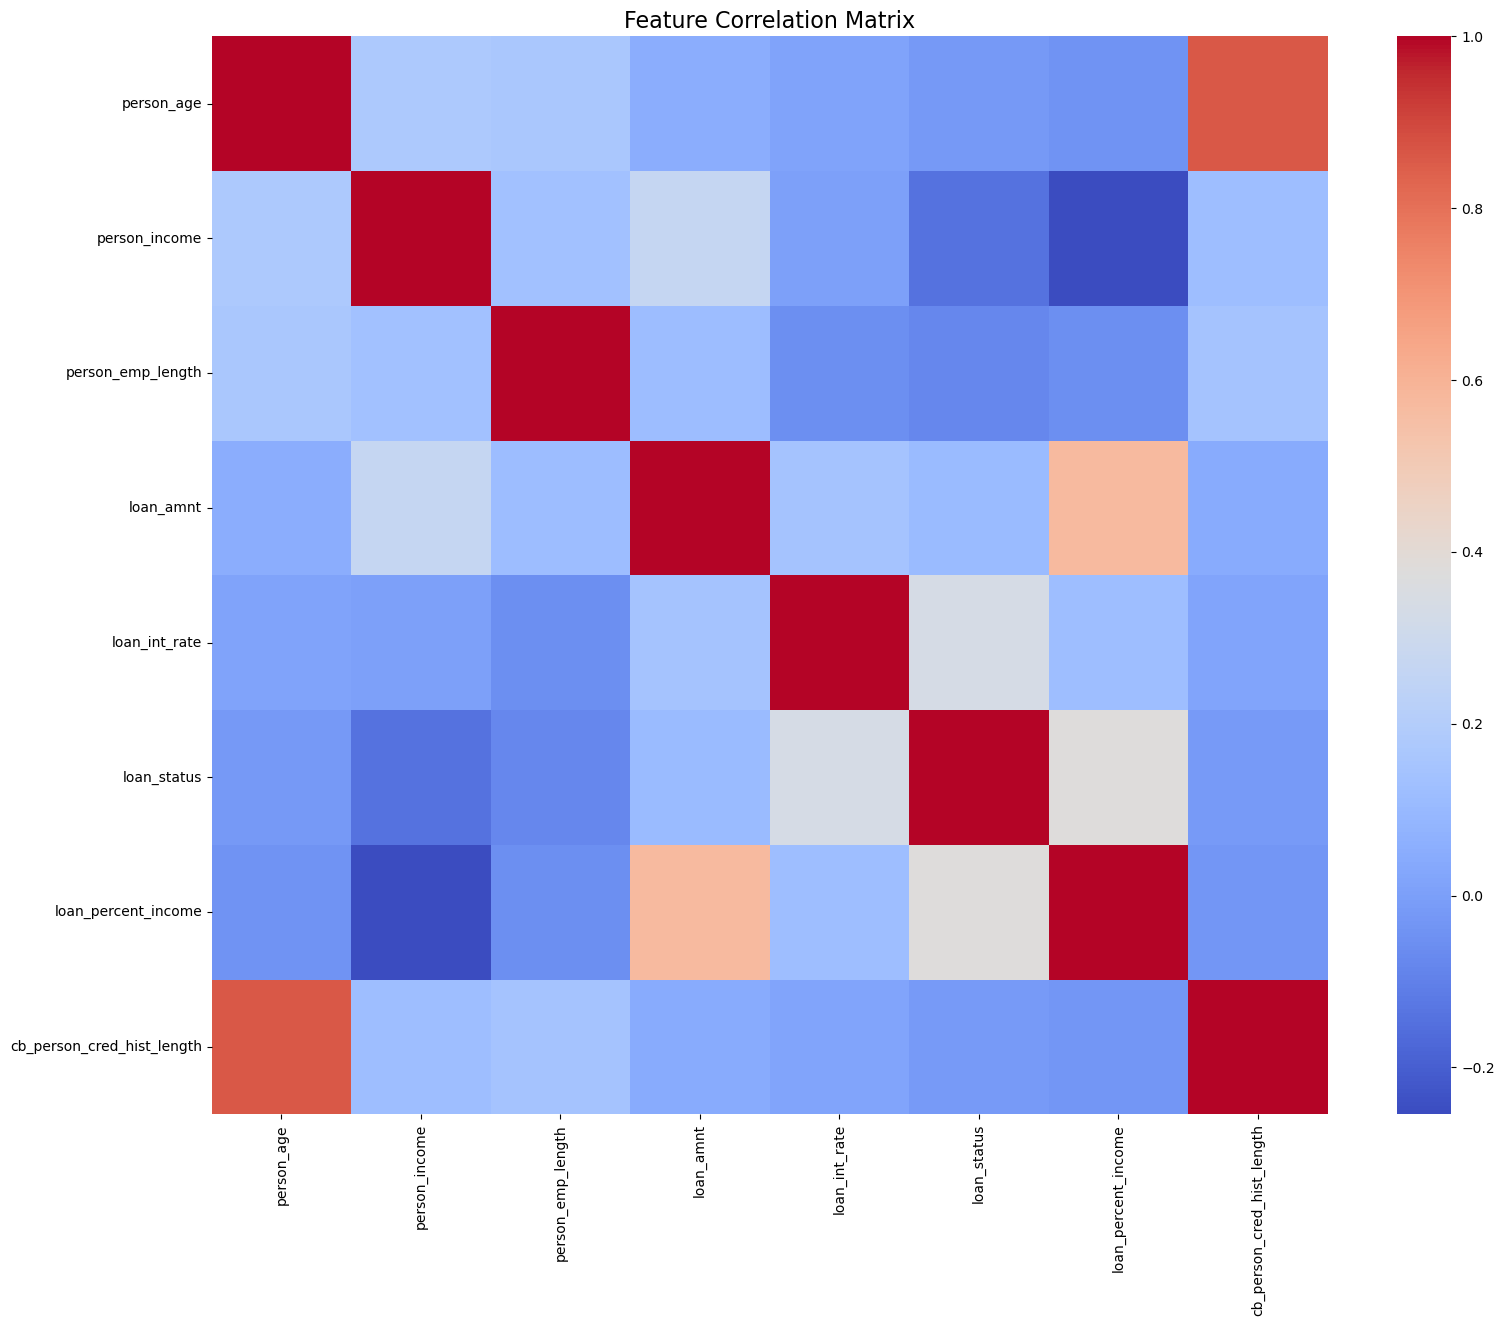

In [10]:
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm');
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

## Observation
The heatmap reveals several notable correlations. `loan_percent_income` (loan amount as % of income) shows a strong positive correlation with the target `loan_status`, indicating that higher debt-to-income ratios are associated with more defaults. `loan_int_rate` also shows a positive correlation with default risk. `person_income` has a negative correlation with the target, suggesting higher income reduces default risk. `loan_amnt` and `loan_int_rate` are moderately correlated, which is expected as larger loans often come with higher rates.

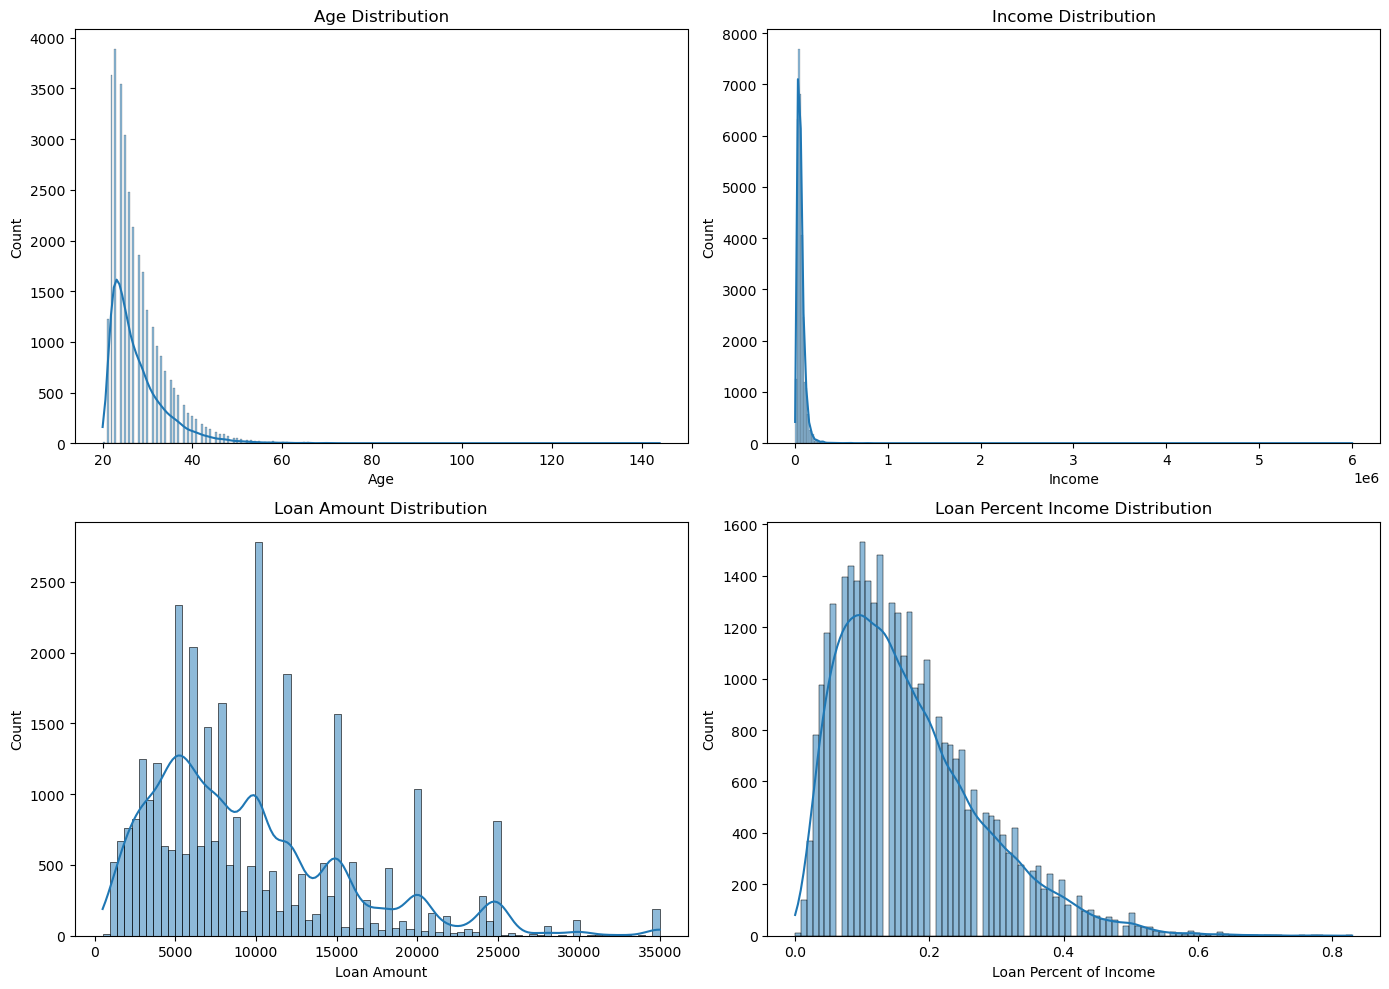

In [11]:
# Plot distributions for key numeric features to inspect their shape and variability.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['person_age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

sns.histplot(df['person_income'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlabel('Income')
axes[0, 1].set_ylabel('Count')

sns.histplot(df['loan_amnt'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Loan Amount Distribution')
axes[1, 0].set_xlabel('Loan Amount')
axes[1, 0].set_ylabel('Count')

sns.histplot(df['loan_percent_income'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Loan Percent Income Distribution')
axes[1, 1].set_xlabel('Loan Percent of Income')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Observation
`person_age` shows a roughly normal distribution centered around late 20s to early 30s, with a slight right skew. `person_income` is heavily right-skewed with most borrowers earning under $100,000, but a long tail of high earners. `loan_amnt` appears relatively uniform with a slight concentration around certain loan amounts (possibly standardized products). `loan_percent_income` shows a right-skewed distribution, indicating most borrowers have moderate debt-to-income ratios, but some have very high ratios which could signal higher risk.

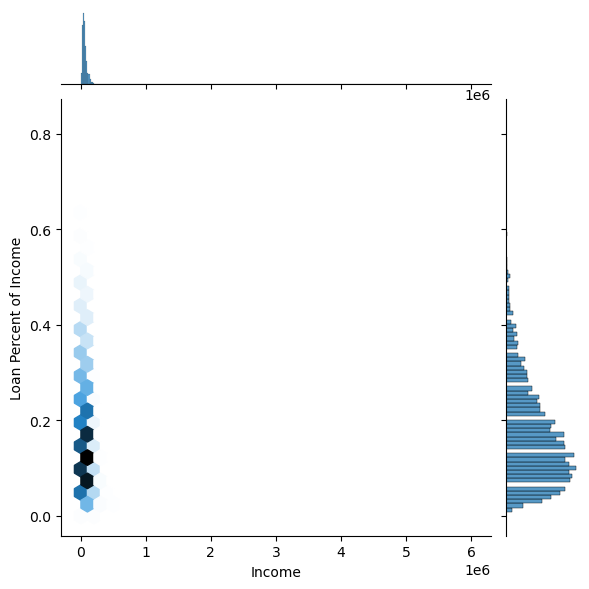

In [12]:
# Visualize the relationship between income and loan percent income using a hexbin-style joint plot.
sns.jointplot(x='person_income', y='loan_percent_income', data=df, kind='hex', gridsize=30)
plt.xlabel('Income')
plt.ylabel('Loan Percent of Income')
plt.show()

## Observation
There is a clear negative relationship between income and loan percent income. Lower income borrowers tend to have higher loan-to-income ratios, which makes sense as they may need to borrow more relative to their income. The density is concentrated in the low-to-moderate income range with moderate loan percentages. High loan percentages (above 0.4) are more common among lower income borrowers, indicating potential higher risk in this segment.

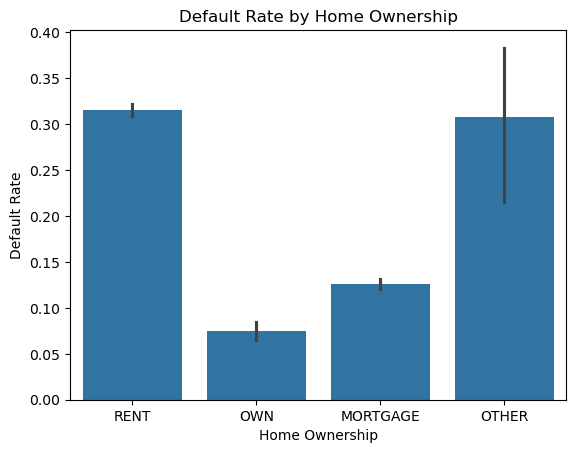

In [13]:
# Compare the default rate by home ownership status.
sns.barplot(x='person_home_ownership', y='loan_status', data=df)
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate')
plt.show()

## Observation
Renters have the highest default rate, followed by those with a mortgage. Owning a home outright or having other ownership types shows lower default rates. This suggests that home ownership status is a meaningful risk indicator, with renters being higher risk compared to homeowners.

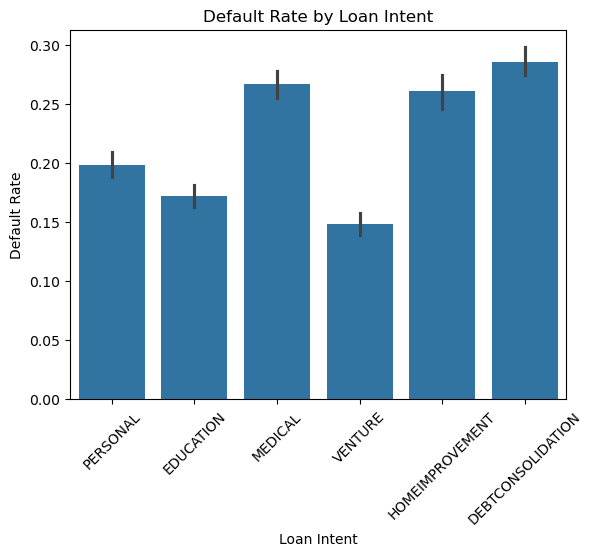

In [14]:
# Compare the default rate by loan intent.
sns.barplot(x='loan_intent', y='loan_status', data=df)
plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

## Observation
Debt consolidation and medical loans have the highest default rates, while education and home improvement loans show lower default rates. This suggests that the purpose of the loan is a meaningful predictor of default risk. Loans for education may have lower risk because borrowers expect higher future earnings, while medical debt may correlate with financial stress.

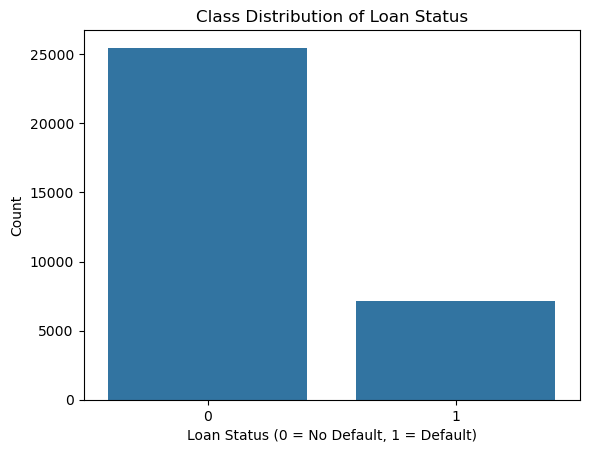

In [15]:
# Count how many records are present in each loan status.
sns.countplot(x='loan_status', data=df)
plt.title('Class Distribution of Loan Status')
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.show()

## Observation
The dataset is imbalanced with approximately 78% non-default (0) and 22% default (1) loans. This class imbalance will need to be addressed during modeling using techniques such as class_weight='balanced' or resampling methods to ensure the model doesn't simply default to predicting the majority class.

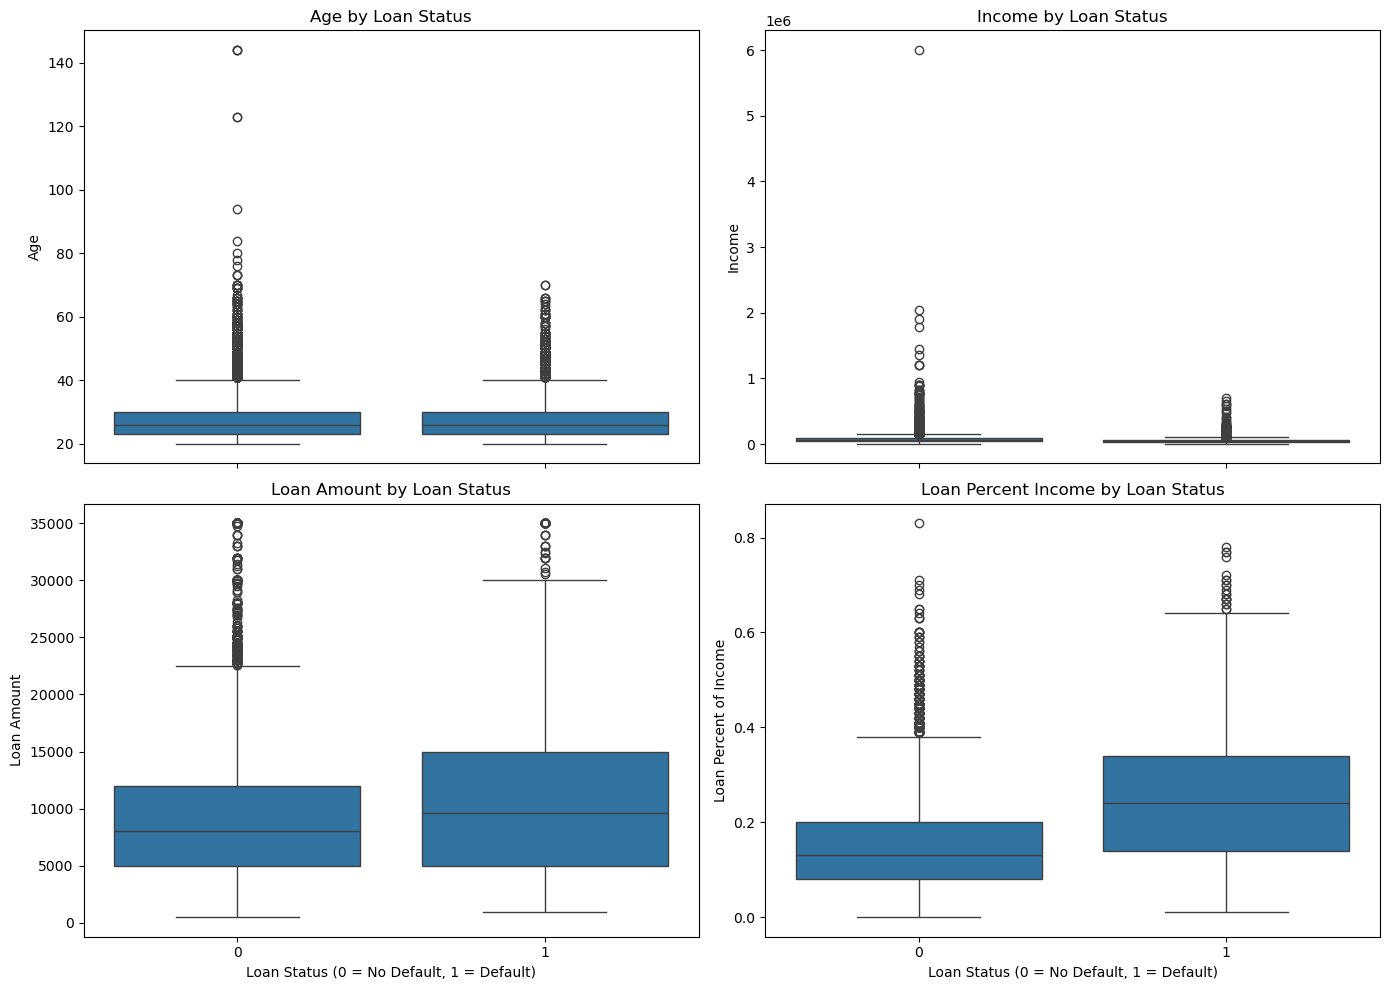

In [16]:
# Compare key numeric features across loan status with multiple boxplots.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

sns.boxplot(x='loan_status', y='person_age', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Age by Loan Status')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Age')

sns.boxplot(x='loan_status', y='person_income', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Income by Loan Status')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Income')

sns.boxplot(x='loan_status', y='loan_amnt', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Loan Amount by Loan Status')
axes[1, 0].set_xlabel('Loan Status (0 = No Default, 1 = Default)')
axes[1, 0].set_ylabel('Loan Amount')

sns.boxplot(x='loan_status', y='loan_percent_income', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Loan Percent Income by Loan Status')
axes[1, 1].set_xlabel('Loan Status (0 = No Default, 1 = Default)')
axes[1, 1].set_ylabel('Loan Percent of Income')

plt.tight_layout()
plt.show()

## Observation
The boxplots reveal clear patterns between features and loan default. Defaulters tend to have slightly lower ages on average. Interestingly, defaulters have higher median loan amounts and significantly higher loan-to-income ratios. The `loan_percent_income` shows the strongest separation between default and non-default groups, confirming it as a key risk indicator. Income appears slightly lower for defaulters, but the difference is less pronounced than for loan-related features.